# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [1]:
from IPython.display import SVG, display
import matplotlib.pyplot as plt

import os

# Replace '/path/to/new/cache' with your desired directory
os.environ["HF_HOME"] = "./.cache"
print(os.environ["HF_HOME"])

from datasets import load_dataset, concatenate_datasets, DatasetDict, Value

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


from torch.optim import AdamW
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm
from scipy.optimize import curve_fit


import re
import time

import mup
from mup import MuReadout, make_base_shapes, set_base_shapes, MuSGD, MuAdam

./.cache


c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lig

# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [2]:
# dataset_1 = load_dataset("starvector/svg-icons-simple")
# dataset_1 = dataset_1.cast_column("Filename", Value("string"))

# dataset_2 = load_dataset("starvector/svg-emoji-simple")
# dataset_2 = dataset_2.cast_column("Filename", Value("string"))

dataset_3 = load_dataset("starvector/svg-stack-simple")
dataset_3 = dataset_3.cast_column("Filename", Value("string"))

# Combine all splits using a dictionary comprehension
combined_dataset = DatasetDict(
    {
        split: concatenate_datasets(
            # [dataset_1[split], dataset_2[split], dataset_3[split]]
            [dataset_3[split]]
        )
        # for split in dataset_1.keys()
        for split in dataset_3.keys()
    }
)

total_items = 300000

dataset = combined_dataset["train"].select(range(total_items))

print(dataset)

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 300000
})


### View Sample


In [3]:
# sample_1 = dataset["Svg"][2]

In [4]:
# print(sample_1)
# display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [5]:
def clean_svg(svg_text):
    # 1. Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # 2. Function to clean ONLY the path data string
    def clean_path_data(match):
        path_string = match.group(1)

        # Space out the letters (M, L, C, Z, etc.)
        path_string = re.sub(r"([a-zA-Z])", r" \1 ", path_string)

        # Replace commas with spaces
        path_string = path_string.replace(",", " ")

        # Round numbers to 1 decimal place
        def round_match(m):
            try:
                return f"{float(m.group(0)):.1f}"
            except ValueError:
                return m.group(0)

        path_string = re.sub(r"-?\d*\.?\d+", round_match, path_string)

        # Clean up any messy double-spaces inside the quotes
        path_string = re.sub(r"\s+", " ", path_string).strip()

        # Return it wrapped back in d="..."
        return f'd="{path_string}"'

    # 3. Apply the cleaner ONLY to the d="..." attributes
    svg_text = re.sub(r'd="([^"]+)"', clean_path_data, svg_text)

    # 4. Clean up any overall messy whitespace
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text


# # Example Test:
# raw_svg = '<svg><path d="M10,20.35L.5 30"/></svg>'
# print(clean_svg(raw_svg))

In [6]:
# svg_string = clean_svg(sample_1)
# print(svg_string)

### Clean and verify all svgs in training set


In [7]:
TOKEN_THRESHOLD = 2048

In [8]:
from svg_utils import process_row

In [9]:
print("Cleaning datasets with multiprocessing...")
cleaned_dataset = dataset.map(process_row, num_proc=8)
print("Done!")

remaining_items = len(cleaned_dataset)
print(remaining_items)

Cleaning datasets with multiprocessing...
Done!
300000


In [10]:
stop_1 = int(remaining_items * 0.98)
stop_2 = stop_1 + int(remaining_items * 0.01)
stop_3 = stop_2 + int(remaining_items * 0.01)

cleaned_train = cleaned_dataset.select(range(stop_1))
cleaned_val = cleaned_dataset.select(range(stop_1, stop_2))
cleaned_test = cleaned_dataset.select(range(stop_2, stop_3))

In [11]:
cleaned_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 294000
})

In [12]:
cleaned_val

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [13]:
cleaned_test

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [14]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


# valid_render runs very long and hasn't filtered out any svg yet... SKIP!

# def valid_render(d):
#     svg_string = d["Svg"]

#     try:
#         cairosvg.svg2png(bytestring=svg_string.encode("utf-8"))
#     except:
#         return False

#     return True


filtered_train = cleaned_train.filter(is_valid)
# filtered_train = filtered_train.filter(valid_render)

In [15]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 204630


## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [16]:
# small initials

VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [17]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [18]:
try:
    tokenizer = Tokenizer.from_file("tokenizer.json")
except:
    print("No tokenizer found in root!")

    tokenizer = Tokenizer(models.BPE())

    tokenizer.pre_tokenizer = pre_tokenizers.Sequence(
        [pre_tokenizers.WhitespaceSplit(), pre_tokenizers.Punctuation()]
    )

    trainer = trainers.BpeTrainer(
        special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
    )

    tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

    tokenizer.save("tokenizer.json")

In [19]:
# sample_2 = filtered_train["Svg"][0]
# sample_2

In [20]:
# encoded_sample_2 = tokenizer.encode(sample_2)

# print(encoded_sample_2)


# # First 10 tokens on encoding
# for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
#     print(f"{id} -> {token}")

In [21]:
# tokenizer.decode(encoded_sample_2.ids)

In [22]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [23]:
tokenized_train = filtered_train.map(tokenize_svg)

In [24]:
# tokenized_train["input_ids"]

In [25]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tqdm(tokenized_dataset["input_ids"]):
        concat_arr.extend(arr)

    return concat_arr


train_input_ids = flatten_input_ids(tokenized_train)
train_input_ids = np.array(train_input_ids)

len(train_input_ids)

  0%|          | 0/204630 [00:00<?, ?it/s]

130428077

In [26]:
print(f"len(np.unique(train_input_ids)): {len(np.unique(train_input_ids))}")

len(np.unique(train_input_ids)): 940


### Create, clean, filter, and tokenize test/val datasets


In [27]:
filtered_test = cleaned_test.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)
test_input_ids = np.array(test_input_ids)

filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)
val_input_ids = np.array(val_input_ids)

  0%|          | 0/2066 [00:00<?, ?it/s]

  0%|          | 0/2088 [00:00<?, ?it/s]

In [28]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 133084710
Number of tokens in train: 130428077 -> 98.00%
Number of tokens in val: 1355632 -> 1.02%
Number of tokens in test: 1301001 -> 0.98%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


## 2.0 Setup


### 2.0.0 Dataloaders


In [29]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert to 1D tensors
train_data = torch.tensor(train_input_ids, dtype=torch.long)
val_data = torch.tensor(val_input_ids, dtype=torch.long)

# We want sequences of length (BLOCK_SIZE + 1)
# Assuming you still have BLOCK_SIZE = 256 from your earlier cell
seq_len = BLOCK_SIZE + 1


def chunk_data(data, seq_len):
    # Calculate how many full sequences we can make
    num_chunks = len(data) // seq_len

    # Truncate any leftover tokens at the very end that don't fit into a full chunk
    data = data[: num_chunks * seq_len]

    # Reshape the 1D tensor into a 2D grid of shape (num_chunks, seq_len)
    return data.view(num_chunks, seq_len)


# 2. Reshape 1D streams into 2D grids
train_data_2d = chunk_data(train_data, seq_len)
val_data_2d = chunk_data(val_data, seq_len)

# 3. NOW we can slice into X and Y safely!
# X gets everything except the last token of each chunk
X_train = train_data_2d[:, :-1]
# Y gets everything except the first token of each chunk
Y_train = train_data_2d[:, 1:]

X_val = val_data_2d[:, :-1]
Y_val = val_data_2d[:, 1:]

# 4. Bundle into TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"X shape: {X_train.shape}, Y shape: {Y_train.shape}")

X shape: torch.Size([507502, 256]), Y shape: torch.Size([507502, 256])


### 2.0.1 Define Model and Functions


In [30]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        self.head_size = head_size

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (d_model)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (self.head_size**-0.5)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()

        head_size = d_model // n_heads

        self.heads = nn.ModuleList(
            [Head(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):

        # Runs input through each attention head, and glues them together side-by-side
        x = torch.concat([head(x) for head in self.heads], dim=-1)

        # Mixes the (head_size x n_heads) head outputs back to one d_model dimensional layer
        x = self.proj(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class CustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [31]:
def estimate_loss(model, val_loader, eval_iters=50):

    model.eval()
    with torch.inference_mode():
        losses = torch.zeros(eval_iters)
        val_iter = iter(val_loader)

        for k in range(eval_iters):
            try:
                X, Y = next(val_iter)
            except StopIteration:
                val_iter = iter(val_loader)
                X, Y = next(val_iter)

            X, Y = X.to(device), Y.to(device)

            _, loss = model(X, targets=Y)

            losses[k] = loss.item()

    model.train()
    return losses.mean().item()


def train_loop(
    model, optimizer, train_loader, val_loader, steps, scheduler=None, eval_interval=100
):
    model.train()
    train_iter = iter(train_loader)

    # --- METRICS TRACKING ---
    train_loss_history = []
    total_tokens_processed = 0
    start_time = time.time()

    # Reset GPU memory stats if using CUDA
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    for step in range(steps):
        try:
            X, Y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            X, Y = next(train_iter)

        X, Y = X.to(device), Y.to(device)
        total_tokens_processed += X.numel()  # Batch_size * Sequence_length

        _, loss = model(X, targets=Y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )  # Clipping gradients
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        train_loss_history.append(loss.item())

        if step % eval_interval == 0 or step == steps - 1:
            current_lr = optimizer.param_groups[0]["lr"]
            val_loss = estimate_loss(model, val_loader)
            print(
                f"Step {step:04d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | lr: {current_lr:.9e}"
            )

    # --- FINALIZE METRICS ---
    end_time = time.time()
    wall_clock_time = end_time - start_time
    tokens_per_sec = total_tokens_processed / wall_clock_time

    max_mem_mb = 0
    if torch.cuda.is_available():
        max_mem_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    final_val_loss = estimate_loss(model, val_loader)

    return {
        "final_val_loss": final_val_loss,
        "train_loss_history": train_loss_history,
        "wall_clock_time": wall_clock_time,
        "tokens_per_sec": tokens_per_sec,
        "gpu_memory_mb": max_mem_mb,
    }

In [ ]:
# Keeping depth the same (n_layers, n_heads) and only varying width (d_model, d_ff)
configs = {
    "Tiny": {"d_model": 128, "n_layers": 6, "n_heads": 6, "d_ff": 512},
    "Small": {"d_model": 192, "n_layers": 6, "n_heads": 6, "d_ff": 768},
    "Medium": {"d_model": 384, "n_layers": 6, "n_heads": 6, "d_ff": 1536},
    "Large": {"d_model": 512, "n_layers": 6, "n_heads": 6, "d_ff": 2048},
    "XL": {"d_model": 768, "n_layers": 6, "n_heads": 6, "d_ff": 3072},
}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 2.0.2 Single Burn Run


In [33]:
def render_svg(s):
    path_strings = re.findall(r'd\s*=\s*"([^"]+)"', s)

    clean_paths = []
    for path_data in path_strings:
        # Clean up tokenizer spaces around dots and numbers (e.g., "1 . 0" -> "1.0")
        clean_data = re.sub(r"\s*\.\s*", ".", path_data)

        # Wrap it in a perfectly formatted path tag
        clean_paths.append(
            f'<path fill="none" stroke="black" stroke-width="0.5" d="{clean_data}" />'
        )

    # 2. Inject the paths into a clean, hardcoded SVG shell
    final_svg = f"""<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="200" height="200">
        {''.join(clean_paths)}
    </svg>"""

    print("--- Extracted and Cleaned SVG ---")
    print(final_svg)
    print("\n--- Rendered Image ---")

    try:
        display(SVG(final_svg))
    except Exception as e:
        print(f"Failed to render: {e}")

In [34]:
# model = CustomTransformer(
#     vocab_size=VOCAB_SIZE,
#     block_size=BLOCK_SIZE,
#     n_layers=4,
#     n_heads=4,
#     d_model=128,
#     d_ff=512,
# ).to(device)

# total_params = sum(p.numel() for p in model.parameters())
# print(f"total_params: {total_params}")

In [35]:
# model.eval()

# with torch.inference_mode():

#     # start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
#     start_context = tokenizer.encode("<svg ").ids
#     # print(start_context)
#     start_point = torch.tensor([start_context], device=device)

#     print(start_point)
#     print(start_point.shape)

#     result = model.generate(start_point, 100)
#     print(result.shape)
#     result = result.squeeze(0).cpu().tolist()
#     result.append(0)

#     print(result)

#     decoded = tokenizer.decode(result)

#     print(decoded)

# render_svg(decoded)

In [36]:
# optimizer = AdamW(model.parameters())

# temp_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# temp_val_loader = DataLoader(val_dataset, batch_size=64)

# train_loop(model, optimizer, temp_train_loader, temp_val_loader, steps=1000)

In [37]:
# model.eval()

# with torch.inference_mode():
#     result_trained = model.generate(start_point, 500)

#     result_trained = result_trained.squeeze(0).cpu().tolist()

#     result_trained.append(0)

#     # # result_trained.append[start_point]

#     decoded_trained = tokenizer.decode(result_trained)

#     print(decoded_trained)

# render_svg(decoded_trained)

## 2.1 LR Sweep


In [38]:
lrs = np.logspace(-7, -1, num=7)
print(lrs)

[1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01]


In [39]:
lr_results = []
sweep_steps = 1000

print("Starting Learning Rate Sweep on Tiny Model...")

for lr in lrs:
    print(f"\n--- Testing LR: {lr:.1e} ---")

    # 1. RE-INITIALIZE THE MODEL inside the loop so it starts fresh!
    sweep_model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs["Tiny"]
    ).to(device)

    # 2. Initialize the optimizer with the current LR
    optimizer = AdamW(sweep_model.parameters(), lr=lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(sweep_steps * 0.1),  # e.g., 100 warmup steps
        max_epochs=sweep_steps,  # Total training steps
        warmup_start_lr=0.0,  # Warmup starts at 0.0
        eta_min=lr * 0.1,  # Cosine decays down to 10% of max LR
    )

    # 3. Train the model
    # (Replace `train_loop` with whatever your actual training function/loop is called)
    metrics = train_loop(
        sweep_model,
        optimizer,
        train_loader,
        val_loader,
        steps=sweep_steps,
        scheduler=scheduler,
    )

    # For demonstration, assign your actual returned val_loss here
    # val_loss = 0.0

    lr_results.append(metrics["final_val_loss"])
    print(f"Final Val Loss for LR {lr:.1e}: {metrics['final_val_loss']:.4f}")

Starting Learning Rate Sweep on Tiny Model...

--- Testing LR: 1.0e-07 ---


C:\Users\Vince\AppData\Local\Temp\ipykernel_13272\1391538751.py:17: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.1331 | Val Loss: 7.1335 | lr: 1.010101010e-09
Step 0100 | Train Loss: 7.1283 | Val Loss: 7.1292 | lr: 9.999972584e-08
Step 0200 | Train Loss: 7.1204 | Val Loss: 7.1208 | lr: 9.723218602e-08
Step 0300 | Train Loss: 7.1172 | Val Loss: 7.1128 | lr: 8.937082129e-08
Step 0400 | Train Loss: 7.0973 | Val Loss: 7.1056 | lr: 7.736382825e-08
Step 0500 | Train Loss: 7.1015 | Val Loss: 7.0997 | lr: 6.265942746e-08
Step 0600 | Train Loss: 7.0917 | Val Loss: 7.0950 | lr: 4.703118669e-08
Step 0700 | Train Loss: 7.0974 | Val Loss: 7.0916 | lr: 3.236410240e-08
Step 0800 | Train Loss: 7.0831 | Val Loss: 7.0894 | lr: 2.042724144e-08
Step 0900 | Train Loss: 7.0823 | Val Loss: 7.0880 | lr: 1.266036540e-08
Step 0999 | Train Loss: 7.0918 | Val Loss: 7.0871 | lr: 1.000000000e-08
Final Val Loss for LR 1.0e-07: 7.0871

--- Testing LR: 1.0e-06 ---
Step 0000 | Train Loss: 6.9954 | Val Loss: 6.9884 | lr: 1.010101010e-08
Step 0100 | Train Loss: 6.9520 | Val Loss: 6.9486 | lr: 9.999972584e-

In [40]:
# best_lr = 1e-2
best_lr = lrs[np.argmin(lr_results)]

print(f"Lowest val_loss when lr = {best_lr}")

Lowest val_loss when lr = 0.01


## 2.2 Train Model Family


In [41]:
scaling_results = {}

steps_per_epoch = len(train_loader) // 5

print(
    f"Starting Scaling Laws Experiment with Best LR = {best_lr} (1 Epoch = {steps_per_epoch} steps)"
)

for name, config in configs.items():
    print(f"\n{'='*40}")
    print(f"Training {name} Model")
    print(f"{'='*40}")

    # Initialize the model with the specific config
    model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **config
    ).to(device)

    params = count_parameters(model)
    print(f"Parameters: {params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(steps_per_epoch * 0.1),
        max_epochs=steps_per_epoch,
        warmup_start_lr=0.0,
        eta_min=best_lr * 0.1,  # Decay to 10% of max LR
    )

    metrics = train_loop(
        model,
        optimizer,
        train_loader,
        val_loader,
        steps=steps_per_epoch,
        scheduler=scheduler,
        eval_interval=500,
    )

    # Print the requested tracking metrics
    print(f"✅ {name} Finished!")
    print(f"   Final Val Loss: {metrics['final_val_loss']:.4f}")
    print(f"   Wall-clock time: {metrics['wall_clock_time']:.1f} sec")
    print(f"   Throughput: {metrics['tokens_per_sec']:,.0f} tokens/sec")
    print(f"   Peak GPU Memory: {metrics['gpu_memory_mb']:.1f} MB")

    # Save for plotting
    metrics["params"] = params
    scaling_results[name] = metrics

    # Optional: Save the model weights so you can generate SVGs later
    torch.save(model.state_dict(), f"model_{name.lower()}.pt")

Starting Scaling Laws Experiment with Best LR = 0.01 (1 Epoch = 1586 steps)

Training Tiny Model
Parameters: 1,471,208


C:\Users\Vince\AppData\Local\Temp\ipykernel_13272\2087943384.py:24: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.0168 | Val Loss: 7.0103 | lr: 6.369426752e-05
Step 0500 | Train Loss: 0.8167 | Val Loss: 0.8407 | lr: 8.778460641e-03
Step 1000 | Train Loss: 0.7894 | Val Loss: 0.7291 | lr: 4.239977419e-03
Step 1500 | Train Loss: 0.6485 | Val Loss: 0.6681 | lr: 1.078450870e-03
Step 1585 | Train Loss: 0.6814 | Val Loss: 0.6628 | lr: 1.000000000e-03
✅ Tiny Finished!
   Final Val Loss: 0.6628
   Wall-clock time: 106.5 sec
   Throughput: 244,053 tokens/sec
   Peak GPU Memory: 1676.4 MB

Training Small Model
Parameters: 3,100,264
Step 0000 | Train Loss: 7.0956 | Val Loss: 7.0922 | lr: 6.369426752e-05
Step 0500 | Train Loss: 0.7702 | Val Loss: 0.8464 | lr: 8.778460641e-03
Step 1000 | Train Loss: 0.7387 | Val Loss: 0.7285 | lr: 4.239977419e-03
Step 1500 | Train Loss: 0.6644 | Val Loss: 0.6410 | lr: 1.078450870e-03
Step 1585 | Train Loss: 0.6028 | Val Loss: 0.6336 | lr: 1.000000000e-03
✅ Small Finished!
   Final Val Loss: 0.6336
   Wall-clock time: 139.1 sec
   Throughput: 186,767 to

## 2.3 Plots


🎯 FITTED SCALING EXPONENT (alpha): -0.0002


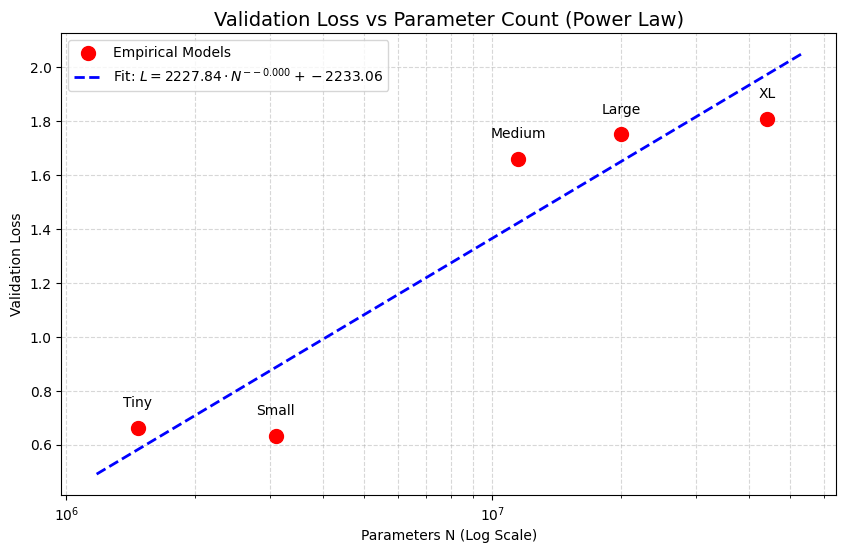

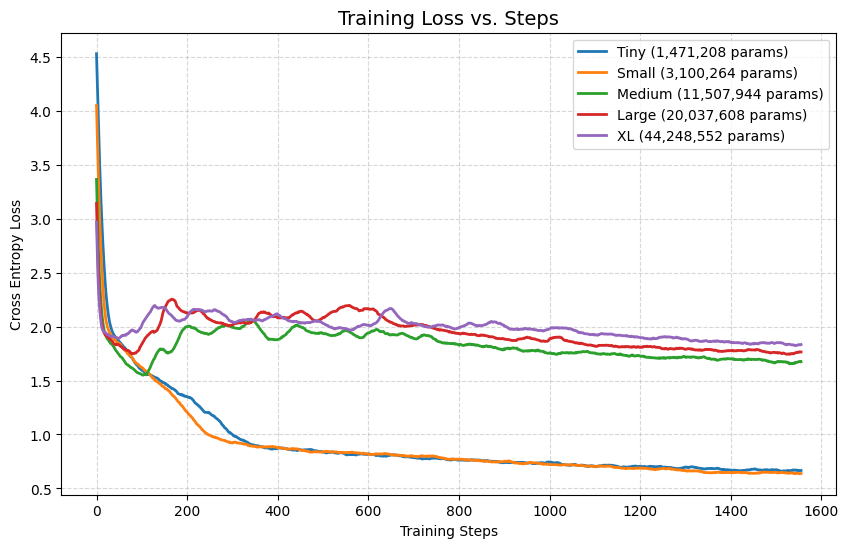

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Extract the data
params_list = np.array([res["params"] for res in scaling_results.values()])
losses_list = np.array([res["final_val_loss"] for res in scaling_results.values()])
names = list(scaling_results.keys())


# 2. Define the Power Law Equation: L(N) = a * N^(-alpha) + c
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c


# 3. Fit the curve! (We provide standard starting guesses [a=1, alpha=0.1, c=0.5])
popt, _ = curve_fit(
    power_law, params_list, losses_list, p0=[1.0, 0.1, 0.5], maxfev=10000
)
a_fit, alpha_fit, c_fit = popt

print(f"🎯 FITTED SCALING EXPONENT (alpha): {alpha_fit:.4f}")

# ==========================================
# Plot 1: The Power Law Scaling Curve
# ==========================================
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(
    params_list, losses_list, color="red", s=100, zorder=5, label="Empirical Models"
)

# Generate smooth line for the fitted curve
x_smooth = np.logspace(
    np.log10(min(params_list) * 0.8), np.log10(max(params_list) * 1.2), 100
)
y_smooth = power_law(x_smooth, *popt)
plt.plot(
    x_smooth,
    y_smooth,
    "b--",
    linewidth=2,
    label=f"Fit: $L = {a_fit:.2f} \cdot N^{{-{alpha_fit:.3f}}} + {c_fit:.2f}$",
)

plt.xscale("log")
for i, name in enumerate(names):
    plt.annotate(
        name,
        (params_list[i], losses_list[i]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
    )

plt.title("Validation Loss vs Parameter Count (Power Law)", fontsize=14)
plt.xlabel("Parameters N (Log Scale)")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig("plots/plot_1.png")
plt.show()

# ==========================================
# Plot 2: Training Loss Curves
# ==========================================
plt.figure(figsize=(10, 6))
for name, res in scaling_results.items():
    # Apply a moving average to smooth the noisy batch losses
    window = max(1, len(res["train_loss_history"]) // 50)
    smoothed_loss = np.convolve(
        res["train_loss_history"], np.ones(window) / window, mode="valid"
    )
    plt.plot(smoothed_loss, label=f"{name} ({res['params']:,} params)", linewidth=2)

plt.title("Training Loss vs. Steps", fontsize=14)
plt.xlabel("Training Steps")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.savefig("plots/plot_2.png")
plt.show()

# 3. µP Scaling and Extrapolation


In Part 2, you tuned the learning rate on the smallest model and used it for all model sizes. In this part,
you will investigate whether µP (Maximal Update Parameterization) can improve scaling behavior by
enabling principled learning rate transfer across model widths. You will also use your scaling laws to make
predictions beyond the model sizes you trained.


## 3.1 Scaling Study


### 3.1.1 Reparameterize


In [43]:
class MuHead(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        self.head_size = head_size  # Store this

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (d_model)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (self.head_size**-1)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MuMultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()
        head_size = d_model // n_heads
        self.heads = nn.ModuleList(
            [MuHead(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):
        x = torch.concat([head(x) for head in self.heads], dim=-1)
        x = self.proj(x)
        return x


class MuTransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MuMultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class MuCustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                MuTransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = mup.MuReadout(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

### 3.1.2 LR Sweep


In [44]:
lrs = np.logspace(-7, -1, num=7)
print(lrs)

[1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01]


In [45]:
mu_lr_results = []
sweep_steps = 1000

print("Starting Learning Rate Sweep on Tiny Model...")

for lr in lrs:
    print(f"\n--- Testing LR: {lr:.1e} ---")

    # 1. Initialize the model
    base_model = MuCustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs["Tiny"]
    ).to(device)

    # --- NEW: CRITICAL µP STEPS ---
    # Since this is the sweep on the "Tiny" model, the Tiny model IS the base shape.
    # We create a reference shape and attach it to our training model.
    mup.set_base_shapes(
        base_model, None
    )  # Setting base to None makes base_model the reference

    # It is also recommended to apply mup initialization here
    base_model.apply(
        lambda m: (
            mup.init.kaiming_uniform_(m.weight)
            if hasattr(m, "weight") and m.weight.dim() > 1
            else None
        )
    )
    # ------------------------------

    # 2. Use mup.MuAdamW instead of AdamW
    # This is required for µP to handle the internal scaling correctly
    optimizer = mup.MuAdamW(base_model.parameters(), lr=lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(sweep_steps * 0.1),
        max_epochs=sweep_steps,
        warmup_start_lr=0.0,
        eta_min=lr * 0.1,
    )

    # 3. Train the model
    metrics = train_loop(
        base_model,
        optimizer,
        train_loader,
        val_loader,
        steps=sweep_steps,
        scheduler=scheduler,
    )

    # For demonstration, assign your actual returned val_loss here
    # val_loss = 0.0

    mu_lr_results.append(metrics["final_val_loss"])
    print(f"Final Val Loss for LR {lr:.1e}: {metrics['final_val_loss']:.4f}")

Starting Learning Rate Sweep on Tiny Model...

--- Testing LR: 1.0e-07 ---


C:\Users\Vince\AppData\Local\Temp\ipykernel_13272\2105038648.py:35: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 8.3173 | Val Loss: 8.3063 | lr: 1.010101010e-09
Step 0100 | Train Loss: 8.3306 | Val Loss: 8.2845 | lr: 9.999972584e-08
Step 0200 | Train Loss: 8.2257 | Val Loss: 8.2416 | lr: 9.723218602e-08
Step 0300 | Train Loss: 8.2278 | Val Loss: 8.2010 | lr: 8.937082129e-08
Step 0400 | Train Loss: 8.1908 | Val Loss: 8.1643 | lr: 7.736382825e-08
Step 0500 | Train Loss: 8.1391 | Val Loss: 8.1333 | lr: 6.265942746e-08
Step 0600 | Train Loss: 8.0591 | Val Loss: 8.1091 | lr: 4.703118669e-08
Step 0700 | Train Loss: 8.1015 | Val Loss: 8.0915 | lr: 3.236410240e-08
Step 0800 | Train Loss: 8.0694 | Val Loss: 8.0798 | lr: 2.042724144e-08
Step 0900 | Train Loss: 8.0488 | Val Loss: 8.0727 | lr: 1.266036540e-08
Step 0999 | Train Loss: 8.0837 | Val Loss: 8.0675 | lr: 1.000000000e-08
Final Val Loss for LR 1.0e-07: 8.0675

--- Testing LR: 1.0e-06 ---
Step 0000 | Train Loss: 7.6756 | Val Loss: 7.6927 | lr: 1.010101010e-08
Step 0100 | Train Loss: 7.4989 | Val Loss: 7.4919 | lr: 9.999972584e-

In [46]:
mu_best_lr = lrs[np.argmin(mu_lr_results)]
# mu_best_lr = 1e-2

print(f"Lowest val_loss when lr = {mu_best_lr}")

Lowest val_loss when lr = 0.01


In [47]:
mu_scaling_results = {}

print(
    f"Starting muP Scaling Laws Experiment with Best LR = {mu_best_lr} (1 Epoch = {steps_per_epoch} steps)"
)


base_model = MuCustomTransformer(
    vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs["Tiny"]
).to(device)


for name, config in configs.items():
    print(f"\n{'='*40}")
    print(f"Training {name} Model")
    print(f"{'='*40}")

    # Initialize the model with the specific config
    target_model = MuCustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **config
    ).to(device)

    # if name != "Tiny":

    mup.set_base_shapes(target_model, base_model)

    target_model.apply(
        lambda m: (
            mup.init.kaiming_uniform_(m.weight, a=5**0.5)
            if hasattr(m, "weight") and m.weight.dim() > 1
            else None
        )
    )

    params = count_parameters(target_model)
    print(f"Parameters: {params:,}")

    optimizer = mup.MuAdamW(target_model.parameters(), lr=mu_best_lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(steps_per_epoch * 0.1),
        max_epochs=steps_per_epoch,
        warmup_start_lr=0.0,
        eta_min=mu_best_lr * 0.1,  # Decay to 10% of max LR
    )

    metrics = train_loop(
        target_model,
        optimizer,
        train_loader,
        val_loader,
        steps=steps_per_epoch,
        scheduler=scheduler,
        eval_interval=200,
    )

    # Print the requested tracking metrics
    print(f"✅ {name} Finished!")
    print(f"   Final Val Loss: {metrics['final_val_loss']:.4f}")
    print(f"   Wall-clock time: {metrics['wall_clock_time']:.1f} sec")
    print(f"   Throughput: {metrics['tokens_per_sec']:,.0f} tokens/sec")
    print(f"   Peak GPU Memory: {metrics['gpu_memory_mb']:.1f} MB")

    # Save for plotting
    metrics["params"] = params
    mu_scaling_results[name] = metrics

    # Optional: Save the model weights so you can generate SVGs later
    torch.save(target_model.state_dict(), f"mu_model_{name.lower()}.pt")

Starting muP Scaling Laws Experiment with Best LR = 0.01 (1 Epoch = 1586 steps)

Training Tiny Model
Parameters: 1,471,208


C:\Users\Vince\AppData\Local\Temp\ipykernel_13272\224901914.py:40: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.1895 | Val Loss: 7.1878 | lr: 6.369426752e-05
Step 0200 | Train Loss: 1.1695 | Val Loss: 1.1615 | lr: 9.979879496e-03
Step 0400 | Train Loss: 0.8347 | Val Loss: 0.8718 | lr: 9.372129102e-03
Step 0600 | Train Loss: 0.8297 | Val Loss: 0.8102 | lr: 8.026754389e-03
Step 0800 | Train Loss: 0.8069 | Val Loss: 0.7630 | lr: 6.200043584e-03
Step 1000 | Train Loss: 0.7332 | Val Loss: 0.7039 | lr: 4.239977419e-03
Step 1200 | Train Loss: 0.7372 | Val Loss: 0.6517 | lr: 2.519940259e-03
Step 1400 | Train Loss: 0.6463 | Val Loss: 0.6253 | lr: 1.367591956e-03
Step 1585 | Train Loss: 0.6350 | Val Loss: 0.6107 | lr: 1.000000000e-03
✅ Tiny Finished!
   Final Val Loss: 0.6107
   Wall-clock time: 114.2 sec
   Throughput: 227,462 tokens/sec
   Peak GPU Memory: 2048.7 MB

Training Small Model
Parameters: 3,100,264
Step 0000 | Train Loss: 6.7054 | Val Loss: 6.7072 | lr: 4.246284501e-05
Step 0200 | Train Loss: 1.1708 | Val Loss: 1.1373 | lr: 6.653998201e-03
Step 0400 | Train Loss: 0.7

### 3.1.3 Plots


🎯 FITTED SCALING EXPONENT (alpha): 0.6386


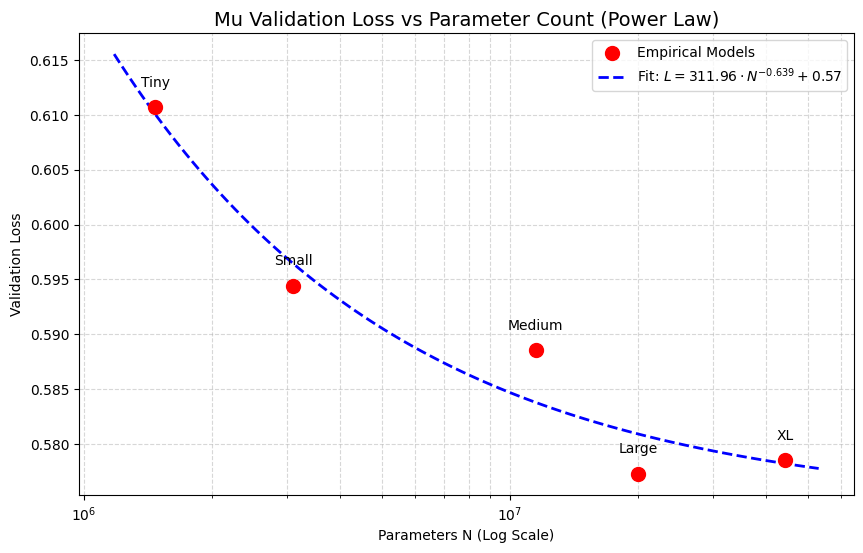

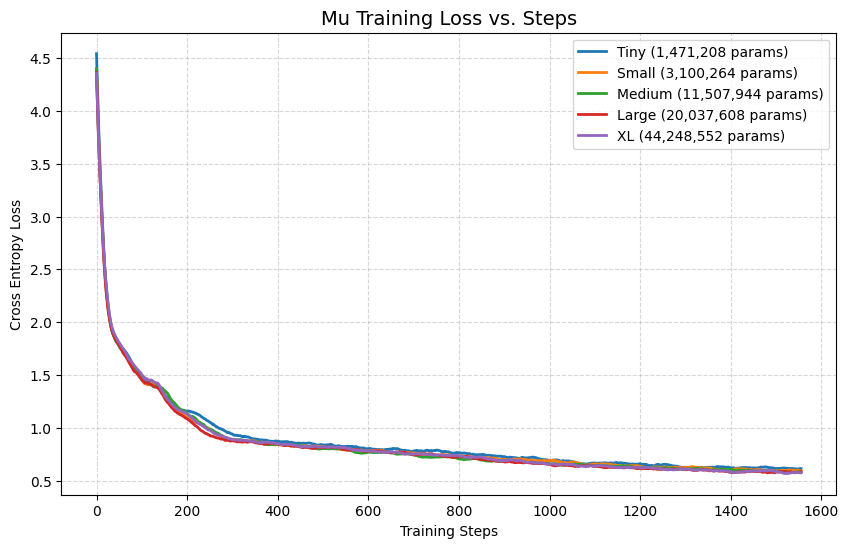

In [ ]:
# 1. Extract the data
params_list = np.array([res["params"] for res in mu_scaling_results.values()])
losses_list = np.array([res["final_val_loss"] for res in mu_scaling_results.values()])
names = list(mu_scaling_results.keys())


# 2. Define the Power Law Equation: L(N) = a * N^(-alpha) + c
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c


# 3. Fit the curve! (We provide standard starting guesses [a=1, alpha=0.1, c=0.5])
popt, _ = curve_fit(
    power_law, params_list, losses_list, p0=[1.0, 0.1, 0.5], maxfev=10000
)
a_fit, alpha_fit, c_fit = popt

print(f"🎯 FITTED SCALING EXPONENT (alpha): {alpha_fit:.4f}")

# ==========================================
# Plot 1: The Power Law Scaling Curve
# ==========================================
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(
    params_list, losses_list, color="red", s=100, zorder=5, label="Empirical Models"
)

# Generate smooth line for the fitted curve
x_smooth = np.logspace(
    np.log10(min(params_list) * 0.8), np.log10(max(params_list) * 1.2), 100
)
y_smooth = power_law(x_smooth, *popt)
plt.plot(
    x_smooth,
    y_smooth,
    "b--",
    linewidth=2,
    label=f"Fit: $L = {a_fit:.2f} \cdot N^{{-{alpha_fit:.3f}}} + {c_fit:.2f}$",
)

plt.xscale("log")
for i, name in enumerate(names):
    plt.annotate(
        name,
        (params_list[i], losses_list[i]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
    )

plt.title("Mu Validation Loss vs Parameter Count (Power Law)", fontsize=14)
plt.xlabel("Parameters N (Log Scale)")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig("plots/mu_plot_1.png")
plt.show()

# ==========================================
# Plot 2: Training Loss Curves
# ==========================================
plt.figure(figsize=(10, 6))
for name, res in mu_scaling_results.items():
    # Apply a moving average to smooth the noisy batch losses
    window = max(1, len(res["train_loss_history"]) // 50)
    smoothed_loss = np.convolve(
        res["train_loss_history"], np.ones(window) / window, mode="valid"
    )
    plt.plot(smoothed_loss, label=f"{name} ({res['params']:,} params)", linewidth=2)

plt.title("Mu Training Loss vs. Steps", fontsize=14)
plt.xlabel("Training Steps")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.savefig("plots/mu_plot_2.png")
plt.show()

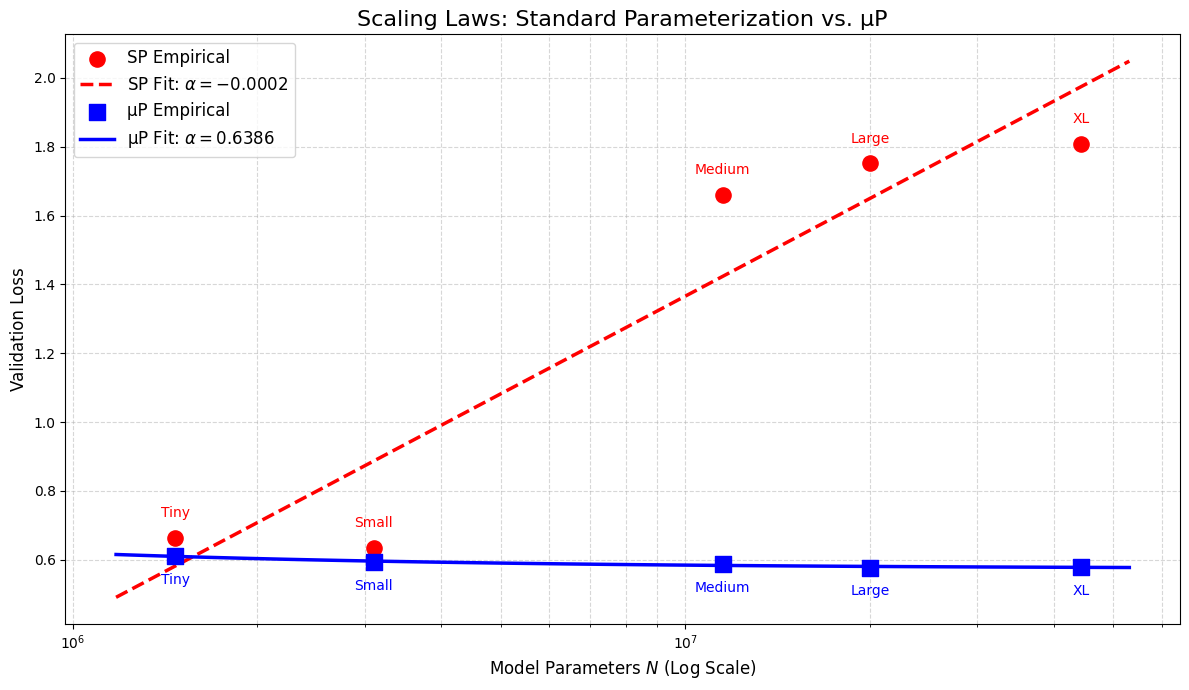

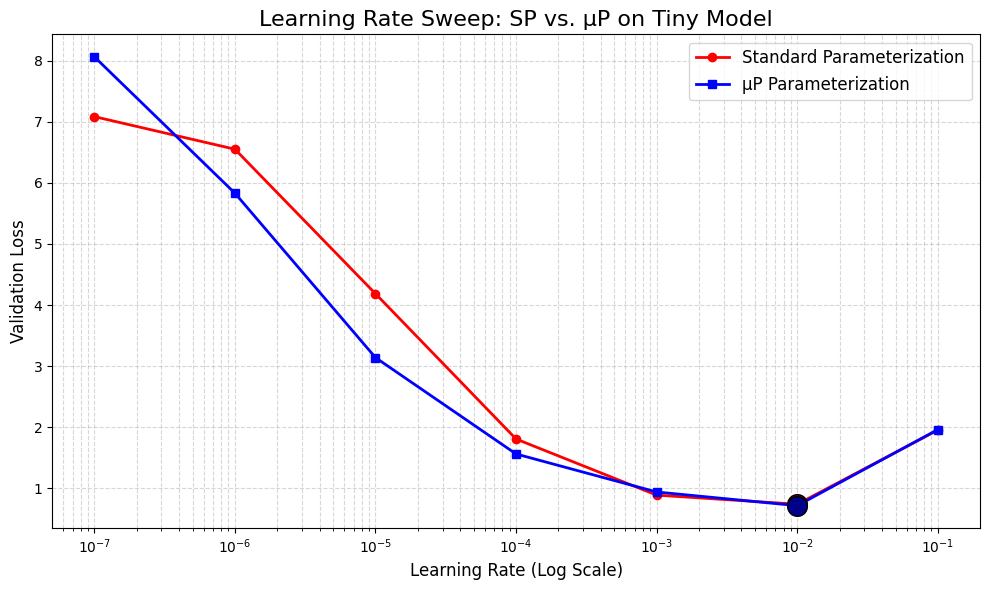

--- FITTED EXPONENT COMPARISON ---
Standard (SP) Alpha : -0.0002
µP Alpha            : 0.6386
Difference          : 0.6388

--- BEST LEARNING RATES ---
Standard (SP) Best LR: 1.0e-02
µP Best LR           : 1.0e-02


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =====================================================================
# DATA EXTRACTION
# Ensure these match the dictionary names you used in your earlier loops
# =====================================================================

# Standard Parameterization (SP) Data
names_sp = list(scaling_results.keys())
params_sp = [res["params"] for res in scaling_results.values()]
losses_sp = [res["final_val_loss"] for res in scaling_results.values()]

# Maximal Update Parameterization (µP) Data
names_mup = list(mu_scaling_results.keys())
params_mup = [res["params"] for res in mu_scaling_results.values()]
losses_mup = [res["final_val_loss"] for res in mu_scaling_results.values()]


# Power Law Function
def power_law(N, a, alpha, c):
    return a * (N**-alpha) + c


# =====================================================================
# 1 & 2. COMBINED SCALING CURVES & POWER LAW FITS
# =====================================================================
plt.figure(figsize=(12, 7))

# --- Fit & Plot Standard Parameterization (SP) ---
popt_sp, _ = curve_fit(
    power_law, params_sp, losses_sp, p0=[1.0, 0.1, 0.5], maxfev=10000
)
a_sp, alpha_sp, c_sp = popt_sp

x_smooth_sp = np.logspace(
    np.log10(min(params_sp) * 0.8), np.log10(max(params_sp) * 1.2), 100
)
y_smooth_sp = power_law(x_smooth_sp, *popt_sp)

plt.scatter(
    params_sp, losses_sp, color="red", s=120, zorder=5, marker="o", label="SP Empirical"
)
plt.plot(
    x_smooth_sp,
    y_smooth_sp,
    "r--",
    linewidth=2.5,
    label=f"SP Fit: $\\alpha = {alpha_sp:.4f}$",
)

# --- Fit & Plot Maximal Update Parameterization (µP) ---
popt_mup, _ = curve_fit(
    power_law, params_mup, losses_mup, p0=[1.0, 0.1, 0.5], maxfev=10000
)
a_mup, alpha_mup, c_mup = popt_mup

x_smooth_mup = np.logspace(
    np.log10(min(params_mup) * 0.8), np.log10(max(params_mup) * 1.2), 100
)
y_smooth_mup = power_law(x_smooth_mup, *popt_mup)

plt.scatter(
    params_mup,
    losses_mup,
    color="blue",
    s=120,
    zorder=5,
    marker="s",
    label="µP Empirical",
)
plt.plot(
    x_smooth_mup,
    y_smooth_mup,
    "b-",
    linewidth=2.5,
    label=f"µP Fit: $\\alpha = {alpha_mup:.4f}$",
)

# --- Formatting ---
plt.xscale("log")
# plt.yscale("log") # Optional: uncomment if you want log-log scale for y too

# Annotate points
for i, name in enumerate(names_sp):
    plt.annotate(
        name,
        (params_sp[i], losses_sp[i]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        color="red",
    )
for i, name in enumerate(names_mup):
    plt.annotate(
        name,
        (params_mup[i], losses_mup[i]),
        textcoords="offset points",
        xytext=(0, -20),
        ha="center",
        color="blue",
    )

plt.title("Scaling Laws: Standard Parameterization vs. µP", fontsize=16)
plt.xlabel("Model Parameters $N$ (Log Scale)", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("comparison_scaling_laws.png", dpi=300)
plt.show()

# =====================================================================
# 3. LEARNING RATE SWEEP COMPARISON ON TINY MODEL
# =====================================================================
# Ensure `lrs`, `lr_results` (from Part 2), and `mu_lr_results` (from Part 3) exist
plt.figure(figsize=(10, 6))

plt.plot(
    lrs,
    lr_results,
    marker="o",
    linestyle="-",
    color="red",
    linewidth=2,
    label="Standard Parameterization",
)
plt.plot(
    lrs,
    mu_lr_results,
    marker="s",
    linestyle="-",
    color="blue",
    linewidth=2,
    label="µP Parameterization",
)

# Highlight the minimums (Best LRs)
best_lr_idx = np.argmin(lr_results)
mu_best_lr_idx = np.argmin(mu_lr_results)

plt.scatter(
    lrs[best_lr_idx],
    lr_results[best_lr_idx],
    color="darkred",
    s=200,
    zorder=5,
    edgecolor="black",
)
plt.scatter(
    lrs[mu_best_lr_idx],
    mu_lr_results[mu_best_lr_idx],
    color="darkblue",
    s=200,
    zorder=5,
    edgecolor="black",
)

# Formatting
plt.xscale("log")
plt.title("Learning Rate Sweep: SP vs. µP on Tiny Model", fontsize=16)
plt.xlabel("Learning Rate (Log Scale)", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("comparison_lr_sweeps.png", dpi=300)
plt.show()

# Print quantitative comparison
print(f"--- FITTED EXPONENT COMPARISON ---")
print(f"Standard (SP) Alpha : {alpha_sp:.4f}")
print(f"µP Alpha            : {alpha_mup:.4f}")
print(f"Difference          : {abs(alpha_mup - alpha_sp):.4f}")
print(f"\n--- BEST LEARNING RATES ---")
print(f"Standard (SP) Best LR: {lrs[best_lr_idx]:.1e}")
print(f"µP Best LR           : {lrs[mu_best_lr_idx]:.1e}")